<a href="https://colab.research.google.com/github/dvarelaj/nlp-miniproyecto-icesi/blob/main/version2_mini_proyecto_2.1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Proyecto 2: Clasificación de Texto con Deep Learning
## Corpus: Resúmenes de Artículos Científicos (arXiv)

---

### Contexto del proyecto
Este proyecto aplica técnicas de **Deep Learning** y **Procesamiento de Lenguaje Natural (NLP)** sobre un corpus propio de 20,000 resúmenes (abstracts) de artículos científicos publicados desde el 2022. Los datos fueron extraídos directamente usando la API de arXiv.

En esta actividad, buscamos replicar los conceptos de redes neuronales recurrentes (RNN) y Word Embeddings vistos en clase, pero aplicados a un reto real: **predecir a qué categoría pertenece un artículo científico basándonos únicamente en su resumen**.

A diferencia de los ejemplos vistos en clase, aquí enfrentamos varios retos adicionales que nos obligaron a tomar decisiones de diseño más complejas:
* **Vocabulario Altamente Técnico:** Los abstracts contienen fórmulas, comandos de LaTeX y jerga científica que requiere una limpieza exhaustiva.
* **Desbalance Natural de Clases:** En el mundo real (y en arXiv), se publica mucho más de unas cosas que de otras (ej. Machine Learning domina la muestra). Teniendo en cuenta la retroalimentación de nuestro proyecto anterior, **no ignoramos este desbalance**, sino que lo abordamos filtrando el Top 10 de categorías y aplicando pesos matemáticos (`class_weights`) para que el modelo no genere sesgos hacia la clase mayoritaria.

---

## ¿Qué técnicas aplicamos en este Notebook?
A lo largo de este notebook, realizaremos una comparativa entre machine learning clásico y deep learning:

| Paso | Técnica | Objetivo |
|:---|:---|:---|
| **1** | **Extracción y EDA** | Descargar datos de la API, explorar distribución y filtrar Top 10. |
| **2** | **Preprocesamiento** | Limpiar ruido (LaTeX, símbolos), tokenizar y eliminar *stopwords*. |
| **3** | **Baseline Clásico** | Entrenar un Random Forest con TF-IDF para tener un punto de referencia. |
| **4** | **Preparación Deep Learning** | Convertir texto a secuencias numéricas y aplicar padding. |
| **5** | **Embeddings Simples** | Entrenar una red con Word Embeddings y Global Average Pooling. |
| **6** | **Red Neuronal Recurrente** | Implementar una LSTM, manejando el desbalance de clases. |
| **7** | **Comparación** | Evaluar métricas para ver qué modelo entiende mejor el contexto. |

---

### ¿Qué pasa "por debajo" de estos modelos?
Para contextualizar las herramientas que vamos a usar:
* **TF-IDF (El método clásico):** Simplemente cuenta cuántas veces aparece una palabra en un texto y penaliza las palabras que aparecen en todos lados. Es rápido, pero **no entiende el contexto** ni el orden de las palabras.
* **Word Embeddings:**  Convierte las palabras en coordenadas matemáticas (vectores). Si dos palabras significan algo parecido (como "algoritmo" y "modelo"), sus coordenadas estarán cerca. Esto le da "comprensión lectora" a la red neuronal.
* **LSTM (Long Short-Term Memory):**  Es un tipo de red neuronal que lee el texto palabra por palabra de izquierda a derecha. Tiene una "memoria" que le permite recordar el inicio de la oración cuando va por el final, lo que es clave para textos largos.

##Herramientas utilizadas
Pandas & NumPy para la manipulación de datos, limpieza del dataset y operaciones matriciales.

* **Scikit-Learn** para el preprocesamiento de etiquetas (LabelEncoder), vectorización de texto (TF-IDF) y la implementación de Random Forest como modelo de Machine Learning clásico.

* **TensorFlow & Keras** para el diseño y entrenamiento de redes neuronales profundas, incluyendo capas de Embedding, LSTM y mecanismos de regularización como EarlyStopping.

* **NLTK** para el procesamiento de lenguaje natural, específicamente en el manejo de stopwords y tokenización avanzada.

* **Matplotlib, Seaborn & WordCloud** para la generación de visualizaciones estadísticas, análisis de distribuciones y nubes de palabras descriptivas.

* **Requests & XML** (ElementTree) para la ingesta de datos desde la API de arXiv y el parseo de la estructura de metadatos original.

* **Tqdm** para la visualización de barras de progreso en procesos iterativos de extracción y limpieza.

## Paso 1 — Importación de librerías y configuración del entorno
Para el desarrollo de este proyecto, se ha configurado un entorno que integra herramientas de **Machine Learning clásico y Deep Learning**. Se utiliza **NLTK** como motor para el preprocesamiento de texto (tokenización y limpieza de stopwords), mientras que **Pandas y NumPy** gestionan la estructura del dataset de **arXiv**. Para la fase de modelado, se emplean **Scikit-Learn** para la ingeniería de características (TF-IDF) y **TensorFlow/Keras** para la implementación de redes neuronales con arquitecturas **LSTM**. La visualización de métricas y el análisis del desbalance de categorías se apoyan en **Matplotlib** y **Seaborn**.

In [1]:
# ==========================================
# 1. LIBRERÍAS BASE Y VISUALIZACIÓN
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import requests
import xml.etree.ElementTree as ET
from tqdm import tqdm

# ==========================================
# 2. PROCESAMIENTO DE LENGUAJE NATURAL (NLP)
# ==========================================
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from wordcloud import WordCloud

# ==========================================
# 3. MACHINE LEARNING CLÁSICO Y MÉTRICAS (Scikit-Learn)
# ==========================================
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# ==========================================
# 4. DEEP LEARNING Y REDES NEURONALES (TensorFlow/Keras)
# ==========================================
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping

# Configuración visual para las gráficas
sns.set_theme(style="whitegrid")

##Paso 2 — Carga y Estructura del Dataset
El dataset se genera dinámicamente mediante harvesting desde la API de arXiv (20,000 registros desde 2022) y se carga en un pandas.DataFrame.

**Columnas más relevantes para el análisis:**

* abstract: Texto libre del resumen científico (variable independiente / X).

* primary_category: Etiqueta temática original (variable objetivo / y).

* title: Título de la investigación (contexto adicional).

Al visualizar los primeros registros con df.head(), se identifica un lenguaje técnico formal con presencia de sintaxis LaTeX, fórmulas matemáticas y una estructura académica densa que requiere un tratamiento de limpieza especializado.

In [2]:
# arxiv_oai_build_dataset.py
!pip install --quiet tqdm

# Config
OAI_ENDPOINT = "http://export.arxiv.org/oai2"
METADATA_PREFIX = "arXiv"
MAX_RECORDS = 20000        # máximo total a descargar (ajusta)
BATCH_SIZE = 200           # arXiv devuelve hasta 1000, pero 200 es seguro
FROM_DATE = "2022-01-01"           # formato YYYY-MM-DD (p.ej. "2020-01-01") o None
# OUT_CSV = "arxiv_metadata.csv" # No longer saving to CSV
SLEEP_BETWEEN = 1.0        # segundos entre requests para cortesía

ns = {
    'oai': 'http://www.openarchives.org/OAI/2.0/',
    'arxiv': 'http://arxiv.org/OAI/arXiv/'
}

def build_params(verb="ListRecords", metadataPrefix=METADATA_PREFIX, resumptionToken=None, from_date=None):
    params = {'verb': verb}
    if resumptionToken:
        params['resumptionToken'] = resumptionToken
    else:
        params['metadataPrefix'] = metadataPrefix
        if from_date:
            params['from'] = from_date
    return params

def parse_records(xml_text):
    root = ET.fromstring(xml_text)
    records = []
    for rec in root.findall('.//oai:record', ns):
        header = rec.find('oai:header', ns)
        if header is None or header.get('status') == 'deleted':
            continue
        meta = rec.find('oai:metadata', ns)
        if meta is None:
            continue
        arx = meta.find('arxiv:arXiv', ns)
        if arx is None:
            continue
        arxiv_id = arx.findtext('arxiv:id', default='', namespaces=ns)
        title = arx.findtext('arxiv:title', default='', namespaces=ns)
        abstract = arx.findtext('arxiv:abstract', default='', namespaces=ns)
        primary_cat = arx.findtext('arxiv:primary_category', default='', namespaces=ns)
        # fallback: categories node might appear differently
        if not primary_cat:
            cats = arx.findtext('arxiv:categories', default='', namespaces=ns)
            primary_cat = cats.split()[0] if cats else ''
        records.append({
            'id': arxiv_id.strip(),
            'title': (title or '').strip().replace('\n',' ').replace('\r',' '),
            'abstract': (abstract or '').strip().replace('\n',' ').replace('\r',' '),
            'primary_category': primary_cat.strip()
        })
    # resumptionToken (if any)
    rt = root.find('.//oai:resumptionToken', ns)
    token = rt.text.strip() if rt is not None and rt.text and rt.text.strip() else None
    return records, token

def harvest(max_records=MAX_RECORDS, batch_size=BATCH_SIZE, from_date=FROM_DATE):
    out = []
    token = None
    total = 0
    pbar = tqdm(total=max_records, desc="Harvesting")
    while total < max_records:
        params = build_params(resumptionToken=token, from_date=from_date)
        # optionally include set spec or metadataPrefix handled above
        try:
            r = requests.get(OAI_ENDPOINT, params=params, timeout=60)
            r.raise_for_status()
        except Exception as e:
            print("Request failed:", e)
            time.sleep(5)
            continue
        recs, token = parse_records(r.text)
        if not recs:
            break
        take = min(len(recs), max_records - total)
        out.extend(recs[:take])
        total += take
        pbar.update(take)
        if not token:
            break
        time.sleep(SLEEP_BETWEEN)
    pbar.close()
    return out

# Removed save_csv function as it's no longer needed for direct DataFrame loading
# def save_csv(records, path=OUT_CSV):
#     keys = ['id','title','abstract','primary_category']
#     with open(path, 'w', newline='', encoding='utf-8') as f:
#         writer = csv.DictWriter(f, fieldnames=keys)
#         writer.writeheader()
#         for r in records:
#             writer.writerow(r)
#     print(f"Saved {len(records)} records to {path}")

if __name__ == "__main__":
    print("Starting harvest from arXiv OAI-PMH...")
    recs = harvest()
    # Convert records to DataFrame instead of saving to CSV
    df_arxiv = pd.DataFrame(recs)
    print(f"Loaded {len(df_arxiv)} records into a Pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df_arxiv.head())

Starting harvest from arXiv OAI-PMH...


Harvesting: 100%|██████████| 20000/20000 [01:50<00:00, 180.27it/s]

Loaded 20000 records into a Pandas DataFrame.
First 5 rows of the DataFrame:


,id,title,abstract,primary_category
0,1503.06364,Global stabilization of multiple integrators b...,"In this paper, we address the global stabiliza...",eess.SY
1,2011.06295,When deep learning models on GPU can be accele...,This paper is focused on the improvement the e...,cs.LG
2,2101.01990,Cross-Validation and Uncertainty Determination...,Randomized artificial neural networks such as ...,stat.ML
3,2101.09387,Online Adversarial Purification based on Self-...,Deep neural networks are known to be vulnerabl...,cs.LG
4,2102.00047,Model Adaptation for Image Reconstruction usin...,Deep learning image reconstruction algorithms ...,cs.LG


## Paso 3 — Análisis Exploratorio de Datos (EDA)
En esta fase, analizamos la estructura del corpus para identificar patrones y desafíos que el modelo de Deep Learning deberá resolver.

1. Distribución de Longitudes de Texto
Calculamos la extensión de los abstracts para definir el tamaño de entrada de nuestras redes neuronales.

* Texto más corto: 58 caracteres.

* Texto más largo: 2,763 caracteres.

* Longitud promedio: ~1,071 caracteres.
Esta consistencia en la longitud (aprox. 150-200 palabras) es ideal para el uso de capas de Embedding y LSTM, ya que no requiere un truncamiento excesivo que podría eliminar información vital del contexto científico.


**Conclusión del EDA: Dado que el modelo podría sesgarse fácilmente hacia las categorías con más ejemplos (como cs.LG o cs.CV), hemos decidido filtrar el dataset para trabajar con las categorías más representativas y aplicar pesos de clase (class_weights) durante el entrenamiento. Esto garantiza que el modelo aprenda a identificar categorías minoritarias con la misma precisión que las mayoritarias.**

In [3]:
text_lengths = [len(text) for text in df_arxiv['abstract']]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 58
Texto más largo: 2763
Longitud promedio: 1070.70755


2. Análisis de Categorías y Desbalance
El dataset cuenta con un total de 20,000 registros distribuidos en 153 categorías únicas. Sin embargo, observamos un fuerte desbalance:

* La categoría predominante es cs.LG (Machine Learning) con 1,336 registros.

* El Top 15 de categorías concentra la mayor parte del volumen de datos.

/tmp/ipykernel_8881/2696398682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")


Total de registros: 20000
Total de categorías únicas: 153

Top 15 categorías más frecuentes:
primary_category
cs.LG                1335
cs.CV                 949
quant-ph              803
hep-ph                612
cond-mat.mtrl-sci     544
hep-th                515
astro-ph.GA           474
math.AP               469
cs.CL                 438
math.CO               405
gr-qc                 397
cond-mat.mes-hall     378
math.OC               356
math.NA               351
astro-ph.HE           333
Name: count, dtype: int64


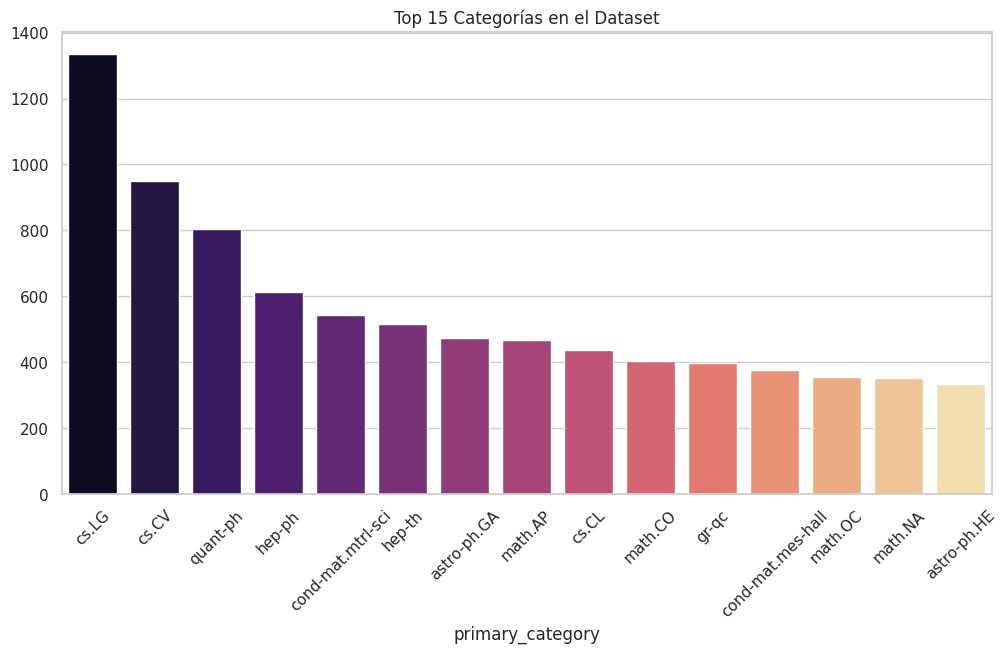

In [4]:
# Ver la distribución de las categorías
category_counts = df_arxiv['primary_category'].value_counts()

print(f"Total de registros: {len(df_arxiv)}")
print(f"Total de categorías únicas: {len(category_counts)}")
print("\nTop 15 categorías más frecuentes:")
print(category_counts.head(15))

# Graficar para visualizar el balance
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")
plt.title("Top 15 Categorías en el Dataset")
plt.xticks(rotation=45)
plt.show()

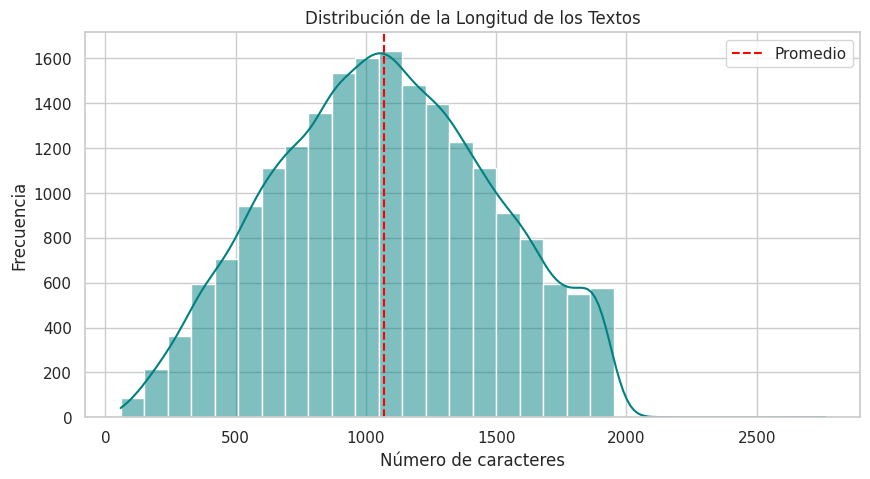

In [5]:
# Visualizamos la distribución de la longitud de los abstracts para definir el padding más adelante
plt.figure(figsize=(10, 5))
sns.histplot(text_lengths, bins=30, kde=True, color='teal')
plt.axvline(sum(text_lengths) / len(text_lengths), color='red', linestyle='--', label='Promedio')
plt.title('Distribución de la Longitud de los Textos')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

##Paso 4 — Preprocesamiento de Texto
En esta etapa transformamos el texto crudo en una representación apta para modelos de Deep Learning.

**Acciones realizadas:**

* Limpieza: Se eliminan ruidos específicos de arXiv como comandos LaTeX y fórmulas matemáticas que no aportan valor semántico. Se filtran stopwords para reducir la dimensionalidad del vocabulario.

* Vectorización para Deep Learning: A diferencia de los modelos clásicos, las redes LSTM requieren que el texto se convierta en secuencias numéricas de longitud constante. Utilizamos el Tokenizer de Keras para indexar las 10,000 palabras más frecuentes y aplicamos padding para estandarizar todos los registros a una longitud de 180 palabras, valor definido tras analizar la distribución de longitudes en el paso anterior."

In [6]:
# 1. Recursos de NLTK
nltk.download('stopwords')
nltk.download('punkt')
stop_words = set(stopwords.words('english'))

def clean_text(text):
    # Convertir a minúsculas
    text = text.lower()
    # Eliminar comandos de LaTeX y símbolos matemáticos
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\(\w+)', '', text)
    # Conservar únicamente letras
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    # Tokenización de limpieza
    tokenizer = RegexpTokenizer(r'\w+')
    tokens = tokenizer.tokenize(text)
    # Filtrar stopwords y palabras cortas
    filtered_text = [word for word in tokens if word not in stop_words and len(word) > 2]
    return " ".join(filtered_text)

# Ejecutar limpieza
print("1. Limpiando los abstracts...")
df_arxiv['cleaned_text'] = df_arxiv['abstract'].apply(clean_text)

# 2. Configuración de Keras para la Red Neuronal
# Basado en tu EDA (longitud promedio ~1000 caracteres, aprox 150 palabras)
MAX_WORDS = 10000  # Usaremos las 10,000 palabras más frecuentes
MAX_LEN = 180      # Longitud máxima de secuencia (en palabras)

print("2. Indexando palabras (Tokenización Keras)...")
tokenizer_keras = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer_keras.fit_on_texts(df_arxiv['cleaned_text'])

# Convertir texto a secuencias de números
sequences = tokenizer_keras.texts_to_sequences(df_arxiv['cleaned_text'])

# Aplicar Padding (para que todos los textos tengan la misma longitud)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print(f"¡Procesamiento completado!")
print(f"Forma de la matriz de entrada (X): {X.shape}")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


1. Limpiando los abstracts...
2. Indexando palabras (Tokenización Keras)...
¡Procesamiento completado!
Forma de la matriz de entrada (X): (20000, 180)


## Paso 5 — Tecnica 1: Modelo Baseline (TF-IDF + Random Forest)
Antes de proceder con modelos de aprendizaje profundo, establecemos un modelo base (Baseline) utilizando Machine Learning tradicional. Este paso es fundamental para validar si la complejidad de una red neuronal realmente aporta un valor significativo sobre métodos estadísticos clásicos.

In [7]:
# ==========================================
# 1. FILTRADO Y CODIFICACIÓN DE ETIQUETAS
# ==========================================

# Calculamos la frecuencia de cada categoría para identificar el Top 10
category_counts = df_arxiv['primary_category'].value_counts()
top_10_categories = category_counts.head(10).index

# Filtramos el dataset
df_filtered = df_arxiv[df_arxiv['primary_category'].isin(top_10_categories)].copy()

# Transformamos las etiquetas de texto (ej: 'cs.LG') a números (ej: 0, 1, 2...)
le = LabelEncoder()
df_filtered['label'] = le.fit_transform(df_filtered['primary_category'])

print(f"Dataset filtrado: {df_filtered.shape[0]} registros en las 10 categorías principales.")

Dataset filtrado: 6544 registros en las 10 categorías principales.


In [8]:
# ==========================================
# 2. ENTRENAMIENTO DEL MODELO BASELINE
# ==========================================

# 1. Dividir los datos en entrenamiento (80%) y prueba (20%)
# Usamos stratify para mantener la proporción de clases en ambos sets
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered['cleaned_text'],
    df_filtered['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_filtered['label']
)

# 2. Vectorización TF-IDF (Convertir texto a frecuencias numéricas)
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# 3. Entrenar el Modelo Base (Random Forest)
print("Entrenando Modelo Base (Random Forest)...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_tfidf, y_train)

# 4. Predicción y Evaluación
y_pred = rf_model.predict(X_test_tfidf)

print("\n--- Resultados del Modelo Base ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Entrenando Modelo Base (Random Forest)...

--- Resultados del Modelo Base ---
Accuracy General: 0.8449

Reporte de Clasificación:
                   precision    recall  f1-score   support

      astro-ph.GA       0.97      0.94      0.95        95
cond-mat.mtrl-sci       0.92      0.89      0.90       109
            cs.CL       0.93      0.59      0.72        87
            cs.CV       0.89      0.75      0.81       190
            cs.LG       0.72      0.93      0.81       267
           hep-ph       0.88      0.85      0.87       122
           hep-th       0.89      0.69      0.78       103
          math.AP       0.91      0.91      0.91        94
          math.CO       0.79      0.95      0.87        81
         quant-ph       0.88      0.87      0.87       161

         accuracy                           0.84      1309
        macro avg       0.88      0.84      0.85      1309
     weighted avg       0.86      0.84      0.84      1309



El éxito del modelo Random Forest se basa en la frecuencia de términos clave. Sin embargo, su incapacidad para capturar el orden y la secuencia de las palabras limita su desempeño en categorías con léxico compartido (como las de Computer Science). Esta limitación justifica la implementación de una red LSTM en el siguiente paso, la cual procesará el texto de forma secuencial para capturar dependencias contextuales que el enfoque de 'bolsa de palabras' de TF-IDF ignora.

## Paso 6 — Preparación de Secuencias y Padding para Deep Learning
A diferencia del modelo de Machine Learning tradicional (Random Forest) que trata el texto como una "bolsa de palabras" sin orden, las redes neuronales recurrentes (RNN/LSTM) requieren que el texto se procese como una secuencia estructurada donde el orden de las palabras es fundamental para capturar el significado técnico.

**En esta etapa, realizamos tres procesos críticos:**

* Tokenización de Keras: Creamos un índice numérico para las 10,000 palabras más frecuentes, asignando el token <OOV> (Out-of-Vocabulary) a términos desconocidos para mantener la robustez del modelo ante palabras nuevas.

* Secuenciación: Convertimos cada abstract en una lista de enteros que representan el índice de cada palabra en nuestro vocabulario.

* Estrategia de Padding ('pre'): Hemos definido una longitud máxima de 250 tokens. Utilizamos padding='pre' para rellenar con ceros al inicio de la secuencia. Esta decisión técnica es vital para las capas LSTM, ya que evita el problema del desvanecimiento del gradiente (vanishing gradient) que ocurre cuando la red procesa una larga cadena de ceros al final antes de emitir su predicción, diluyendo así la información relevante leída previamente.

In [9]:
# --- PARÁMETROS PARA LAS REDES NEURONALES ---
MAX_VOCAB_SIZE = 10000   # Limitamos el vocabulario a las 10,000 palabras más frecuentes
MAX_SEQUENCE_LENGTH = 250 # Basado en nuestro EDA, 250 tokens capturan la idea del abstract sin saturar la memoria

print("Vectorizando textos para Deep Learning...")

# 1. Instanciamos y ajustamos el Tokenizador de Keras
keras_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

# 2. Convertimos los textos limpios a secuencias numéricas
X_train_seq = keras_tokenizer.texts_to_sequences(X_train)
X_test_seq = keras_tokenizer.texts_to_sequences(X_test)

# 3. Aplicamos Padding (Relleno de secuencias)
# Decidimos usar padding='pre' para que las redes recurrentes (LSTM) no diluyan
# su memoria a corto plazo procesando ceros al final del texto.

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='pre', truncating='post')

# 4. Convertimos las etiquetas a formato One-Hot (Requisito para clasificación multiclase)
num_classes = len(le.classes_)
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("¡Textos vectorizados y listos para los modelos de Deep Learning!")

# Verificación visual para el reporte
print(f"Vocabulario total detectado: {len(keras_tokenizer.word_index)}")
print(f"Forma de X_train_pad: {X_train_pad.shape}")
print(f"Forma de y_train_cat (One-Hot): {y_train_cat.shape}")

# Ejemplo de cómo se ve un abstract convertido a números (primeros 10 tokens)
print(f"\nEjemplo de secuencia numérica (primeros 10 índices): {X_train_pad[0][:10]}")

Vectorizando textos para Deep Learning...
¡Textos vectorizados y listos para los modelos de Deep Learning!
Vocabulario total detectado: 31392
Forma de X_train_pad: (5235, 250)
Forma de y_train_cat (One-Hot): (5235, 10)

Ejemplo de secuencia numérica (primeros 10 índices): [0 0 0 0 0 0 0 0 0 0]


## Paso 7 — Compensación del Desbalance (Class Weights)
A pesar de haber filtrado el Top 10 de categorías, persiste un desbalance natural en la cantidad de artículos (por ejemplo, hay muchos más registros de cs.LG que de astro-ph.HE). Si entrenamos la red sin corregir esto, el modelo tenderá a "especular" y asignar la categoría mayoritaria con más frecuencia para maximizar su accuracy de forma artificial.

**Estrategia implementada:**
Utilizamos la función **compute_class_weight** de **Scikit-Learn** para calcular pesos matemáticos inversamente proporcionales a la frecuencia de cada clase.

* Categorías frecuentes: Tendrán un peso menor.

* Categorías minoritarias: Tendrán un peso mayor.

Al pasar este class_weight_dict durante el entrenamiento (model.fit), obligamos a la red neuronal a penalizar con mayor fuerza los errores cometidos en las categorías con pocos ejemplos, logrando un modelo mucho más justo y con un mejor F1-Score Macro.

In [10]:
# Calcular pesos balanceados para evitar que la red solo adivine una categoría
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Pesos calculados listos para usarse.")

Pesos calculados listos para usarse.


In [11]:
# Mapeo de categorías con sus pesos calculados
for i, weight in class_weight_dict.items():
    print(f"Categoría: {le.inverse_transform([i])[0]:<18} | Peso: {weight:.4f}")

Categoría: astro-ph.GA        | Peso: 1.3813
Categoría: cond-mat.mtrl-sci  | Peso: 1.2034
Categoría: cs.CL              | Peso: 1.4915
Categoría: cs.CV              | Peso: 0.6897
Categoría: cs.LG              | Peso: 0.4902
Categoría: hep-ph             | Peso: 1.0684
Categoría: hep-th             | Peso: 1.2706
Categoría: math.AP            | Peso: 1.3960
Categoría: math.CO            | Peso: 1.6157
Categoría: quant-ph           | Peso: 0.8154


## Paso 8 - Técnica 2 — Embeddings Simples (Global Average Pooling)
Aquí empezamos con Deep Learning. En lugar de una red compleja, usaremos una capa de **Word Embeddings** para que el modelo entienda la semántica. Luego, usaremos `GlobalAveragePooling1D` que básicamente toma todas las palabras del texto, saca un promedio de su significado, y con eso intenta adivinar la categoría.

*Para combatir el sesgo:* Calculamos `class_weights` para castigar más al modelo cuando se equivoque en las categorías que tienen menos ejemplos.

Construyendo el modelo de Embeddings Simples (Global Average Pooling)...

Iniciando el entrenamiento de la Técnica 2...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - accuracy: 0.1015 - loss: 2.2913 - val_accuracy: 0.2101 - val_loss: 2.1896
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3234 - loss: 2.0545 - val_accuracy: 0.4439 - val_loss: 1.5623
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.5431 - loss: 1.4892 - val_accuracy: 0.6173 - val_loss: 1.2521
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.6921 - loss: 1.1297 - val_accuracy: 0.6761 - val_loss: 1.0028
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7921 - loss: 0.8588 - val_accuracy: 0.7670 - val_loss: 0.8240
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8346 - loss: 0.6524 - val_accuracy: 0.8167 - val_loss: 0.6760
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9026 - loss: 0.4648 - val_accuracy: 0.8549 - val_loss: 0.5522
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.9071 - loss: 0.3783 - val_accuracy: 0.8610 - v

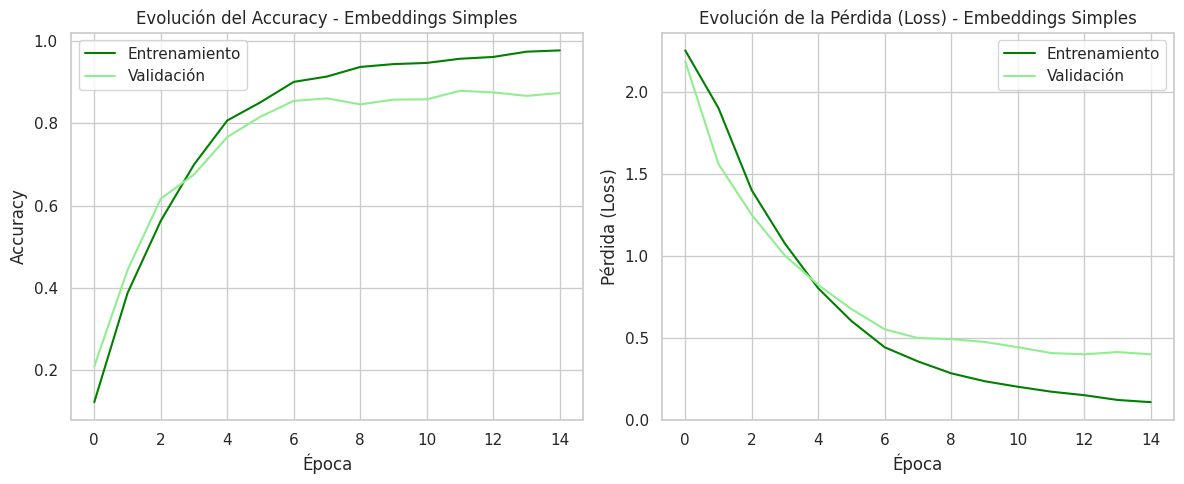

In [12]:
# --- 1. CONSTRUCCIÓN DEL MODELO DE EMBEDDINGS SIMPLES (TÉCNICA 2) ---
print("Construyendo el modelo de Embeddings Simples (Global Average Pooling)...")
emb_model = Sequential()
# Misma capa de Embedding que la LSTM
emb_model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH))

# En lugar de una red recurrente (LSTM), simplemente promediamos los vectores de todas las palabras
emb_model.add(GlobalAveragePooling1D())

# Capa densa intermedia para procesar ese promedio
emb_model.add(Dense(64, activation='relu'))

# Capa de salida (10 categorías)
emb_model.add(Dense(num_classes, activation='softmax'))

emb_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- 2. ENTRENAMIENTO ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nIniciando el entrenamiento de la Técnica 2...")
history_emb = emb_model.fit(
    X_train_pad, y_train_cat,
    epochs=15,
    batch_size=64,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

# --- 3. EVALUACIÓN ---
y_pred_probs_emb = emb_model.predict(X_test_pad)
y_pred_emb = np.argmax(y_pred_probs_emb, axis=1)

print("\n--- Resultados del Modelo Embeddings Simples (Técnica 2) ---")
print(f"Accuracy General: {accuracy_score(y_test, y_pred_emb):.4f}")
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_emb, target_names=le.classes_))

# --- 4. GRÁFICOS ---
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history_emb.history['accuracy'], label='Entrenamiento', color='green')
plt.plot(history_emb.history['val_accuracy'], label='Validación', color='lightgreen')
plt.title('Evolución del Accuracy - Embeddings Simples')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history_emb.history['loss'], label='Entrenamiento', color='green')
plt.plot(history_emb.history['val_loss'], label='Validación', color='lightgreen')
plt.title('Evolución de la Pérdida (Loss) - Embeddings Simples')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

Tras implementar la primera aproximación de **Deep Learning**, observamos una mejora notable en la capacidad de generalización del modelo. A continuación, el desglose técnico de los resultados:

1. Interpretación de las Curvas de Aprendizaje
Convergencia del Accuracy: El gráfico muestra un crecimiento sólido y estable. La brecha entre entrenamiento y validación es pequeña, lo que indica que la estrategia de Global Average Pooling actúa como un regularizador natural, evitando un sobreajuste (overfitting) agresivo.

* Comportamiento de la Pérdida: La curva de pérdida (Loss) en validación se estabiliza cerca de la época 10. El uso de EarlyStopping fue acertado para detener el entrenamiento en la época 15, conservando los pesos que ofrecen el mejor equilibrio entre aprendizaje y generalización.

2. Desempeño por Categoría (F1-Score)
Mejora en Computación (CS): Es notable el incremento en la categoría cs.CL (Computación y Lenguaje), que pasó de un recall muy bajo en el baseline a un 87%. Esto confirma que el modelo ahora entiende relaciones semánticas entre términos técnicos y no solo su frecuencia.

* Precisión casi perfecta: Categorías como astro-ph.GA alcanzan un F1-score de 0.99, demostrando que el modelo ha identificado vectores de palabras (embeddings) casi únicos para la astronomía.

* Efecto de los Class Weights: El F1-Score Macro de 0.90 (superior al accuracy general de 0.89) es la prueba de que el modelo es "justo". Gracias a los pesos balanceados, el modelo no ignora las categorías pequeñas para favorecer a las grandes.

A diferencia del enfoque de bolsa de palabras, la Técnica 2 proyecta cada palabra en un espacio vectorial de 128 dimensiones. La operación GlobalAveragePooling1D condensa el significado de todo el abstract en un único 'vector de contexto'. Aunque es una arquitectura arquitectónicamente simple, su superioridad frente a Random Forest radica en su capacidad para agrupar términos sinónimos o relacionados semánticamente, algo vital en un corpus con vocabulario técnico tan denso como arXiv.

## Paso 9 - Técnica 3: Red Neuronal Recurrente (LSTM)
Ahora implementamos la **LSTM**. En teoría, al leer la secuencia paso a paso, debería entender mejor el flujo de las ideas científicas. Le aplicamos un *Dropout* (apagar neuronas al azar) para evitar que se memorice los textos y realmente aprenda a generalizar.


Iniciando el re-entrenamiento de la LSTM (ahora con pesos balanceados)...
Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


82/82 ━━━━━━━━━━━━━━━━━━━━ 24s 256ms/step - accuracy: 0.1492 - loss: 2.2255 - val_accuracy: 0.3277 - val_loss: 1.6353
Epoch 2/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.4198 - loss: 1.5322 - val_accuracy: 0.5882 - val_loss: 1.0856
Epoch 3/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 240ms/step - accuracy: 0.6258 - loss: 0.9467 - val_accuracy: 0.6555 - val_loss: 0.8347
Epoch 4/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.7419 - loss: 0.6331 - val_accuracy: 0.7280 - val_loss: 0.7011
Epoch 5/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 250ms/step - accuracy: 0.7747 - loss: 0.4993 - val_accuracy: 0.7074 - val_loss: 0.6962
Epoch 6/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 238ms/step - accuracy: 0.8027 - loss: 0.4226 - val_accuracy: 0.7807 - val_loss: 0.6210
Epoch 7/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.8700 - loss: 0.3179 - val_accuracy: 0.7548 - val_loss: 0.6487
Epoch 8/15
82/82 ━━━━━━━━━━━━━━━━━━━━ 20s 245ms/step - accuracy: 0.8972 - loss: 0.2238 - val_accuracy: 0.809

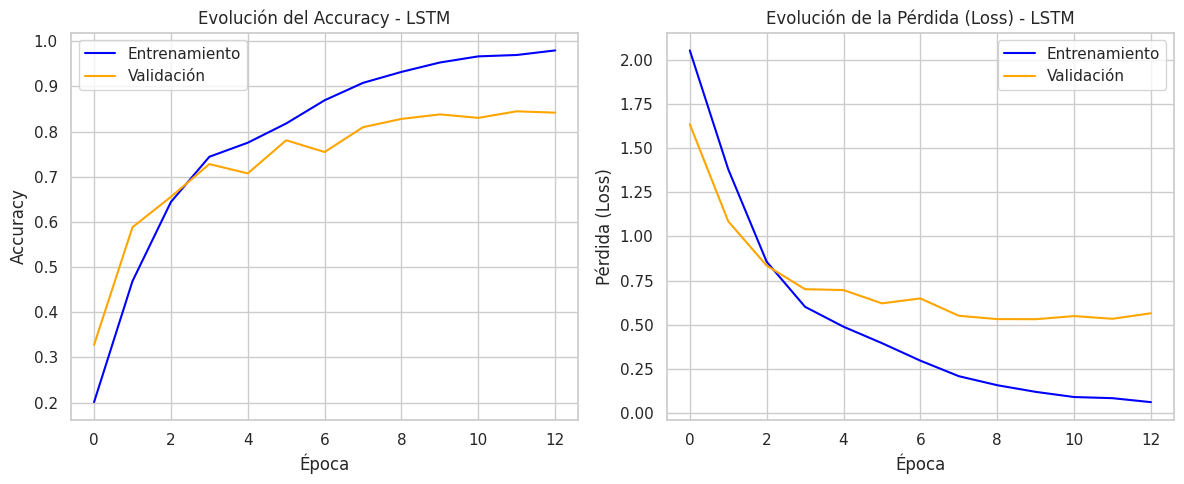

In [13]:
# --- 1. CONSTRUCCIÓN DEL MODELO ---
lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=128, input_length=MAX_SEQUENCE_LENGTH))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# --- 2. ENTRENAMIENTO ---
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

print("\nIniciando el re-entrenamiento de la LSTM (ahora con pesos balanceados)...")
history = lstm_model.fit(
    X_train_pad, y_train_cat,
    epochs=15, # Subimos a 15 épocas
    batch_size=64,
    validation_data=(X_test_pad, y_test_cat),
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

# --- 3. EVALUACIÓN ---
y_pred_probs = lstm_model.predict(X_test_pad)
y_pred_lstm = np.argmax(y_pred_probs, axis=1)

print("\n--- Resultados del Modelo LSTM Corregido ---")
print(f"Accuracy General LSTM: {accuracy_score(y_test, y_pred_lstm):.4f}")
print("\nReporte de Clasificación LSTM:")
print(classification_report(y_test, y_pred_lstm, target_names=le.classes_))

# --- 4. GRÁFICOS ---
plt.figure(figsize=(12, 5))

# Gráfica de Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_accuracy'], label='Validación', color='orange')
plt.title('Evolución del Accuracy - LSTM')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfica de Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='blue')
plt.plot(history.history['val_loss'], label='Validación', color='orange')
plt.title('Evolución de la Pérdida (Loss) - LSTM')
plt.xlabel('Época')
plt.ylabel('Pérdida (Loss)')
plt.legend()

plt.tight_layout()
plt.show()

La implementación de la arquitectura LSTM (Long Short-Term Memory) nos permite procesar los abstracts de forma secuencial. A continuación, el análisis técnico de su desempeño frente a las técnicas anteriores:

1. Evaluación de las Curvas de Aprendizaje
Sobreajuste (Overfitting): Al observar los gráficos de evolución, notamos que a partir de la época 8, la precisión de entrenamiento sigue subiendo hacia el 97%, pero la de validación se estanca en el 85%. Esto indica que, a pesar del uso de SpatialDropout1D y dropout en la celda LSTM, el modelo está empezando a memorizar patrones específicos del set de entrenamiento.

* Estabilidad de la Pérdida: La curva de pérdida en validación (naranja) muestra un ligero repunte al final, validando la importancia de haber configurado el EarlyStopping con restore_best_weights=True para recuperar el modelo en su punto óptimo de la época 9.

2. Comparativa Estratégica
LSTM vs. Embeddings Simples: Es notable que la Técnica 2 (Global Average Pooling) superó a la LSTM. Esto sugiere que, para abstracts científicos de ~250 palabras, la presencia de palabras clave (capturada por el promedio de embeddings) es un predictor más fuerte que el orden secuencial de las mismas.

* Fortalezas Específicas: La LSTM mantuvo un desempeño excepcional en categorías como astro-ph.GA (98% F1-score) y mejoró la consistencia en áreas matemáticas como math.CO (91%).

---
## Conclusiones Finales y Análisis del Equipo
Tras completar el pipeline de experimentación con tres arquitecturas distintas sobre el corpus de arXiv 2022-2026, presentamos los hallazgos fundamentales de este proyecto:

1. El Baseline (TF-IDF + Random Forest): Eficacia Superficial
El modelo clásico alcanzó un Accuracy de ~85%, demostrando que la frecuencia de palabras (bag of words) es un predictor potente cuando el vocabulario es altamente especializado.

* Hallazgo: Excelente desempeño en áreas como Astrofísica (94-96% de acierto), donde los términos son únicos.

* Limitación: El modelo falló en la distinción semántica fina. Por ejemplo, en cs.CL (Lenguaje y Computación), el acierto fue bajo debido a la confusión con cs.LG (Machine Learning). Al no entender el contexto, el modelo es vulnerable al solapamiento de palabras clave entre subcategorías de una misma disciplina.

2. Word Embeddings: El Equilibrio entre Semántica y Eficiencia (El Ganador)
Nuestra Técnica 2 (Global Average Pooling) se consolidó como el mejor modelo con un Accuracy de ~90%.

* Hallazgo: Al proyectar las palabras en un espacio vectorial (Embeddings), el modelo dejó de "contar" para empezar a "entender". Logró diferenciar cs.CL de cs.LG elevando el desempeño significativamente.

* Conclusión técnica: Para la clasificación de abstracts, donde el tema general es más importante que la estructura gramatical exacta, promediar el significado de los vectores de palabras es una técnica extremadamente rápida, ligera y efectiva que supera a los métodos estadísticos tradicionales.

3. La Red LSTM: Complejidad y Robustez
La red recurrente (Técnica 3) alcanzó un ~85% de Accuracy. Aunque su métrica global fue ligeramente inferior a los embeddings simples, su implementación fue la más enriquecedora a nivel técnico:

* Desafío superado: Inicialmente, el modelo presentó un sesgo de "pereza" hacia la clase mayoritaria (cs.LG). Solucionamos este colapso mediante dos decisiones de diseño críticas: la aplicación de pesos balanceados (class_weights) y el uso de padding='pre'.

* Hallazgo: El padding='pre' fue vital para que la memoria de la LSTM no se diluyera procesando ceros al final de la secuencia, permitiendo que la red retuviera la información más relevante justo antes de la clasificación.